In [ ]:
import os, sys, numpy, requests, json, time, re
from pandas import Index, read_csv, read_excel, merge, concat
from pandas import Series, DataFrame, Timestamp, Timedelta
from pandas import DatetimeIndex, TimedeltaIndex
from pandas import to_datetime, date_range
from urllib.parse import urlencode, quote, unquote
from concurrent.futures import ThreadPoolExecutor as Pool
from matplotlib.pyplot import subplots, style as PlotStyle
from matplotlib.ticker import MaxNLocator
from concurrent.futures import as_completed
from enum import IntEnum
import sqlalchemy as sql
from uuid import uuid4

PlotStyle.use("dark_background")

DB_NAME = os.environ.get("DB_NAME")
DB_USER = os.environ.get("DB_USER")
DB_PASS = os.environ.get("DB_PASS")
DB_HOST = os.environ.get("DB_HOST")
DB_PORT = os.environ.get("DB_PORT")
DB_URL = f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
#connDB = sql.create_engine(DB_URL)
#accounts = read_sql(sql = "SELECT * FROM tc_accounts", con = connDB, index_col = "alias")
MT_API_URL = "https://mt5.mtapi.io/{endpoint}?{params}"
DT_FORMAT_FN = "%Y.%m.%d_%H.%M"
DT_FORMAT_API = "%Y-%m-%dT%X"
DT_FORMAT_STR = "%b'%d %X"
DT_FORMAT = "%x %X"

<hr><hr><hr><hr><hr><hr>

<h3><center><font color = "tomato"><b><u>Match-checker for Trade Manager</u></b></font></center></h3>

In [276]:
COLUMNS_ORDERS_MAIN = dict(symbol = "symbol", lots = "lots", orderType = "order",
    openTimestampUTC = "t_entry", closeTimestampUTC = "t_exit", openPrice = "p_entry",
    closePrice = "p_exit", stopLoss = "p_sl", contractSize = "point", takeProfit = "p_tp",
    dealInternalIn = "deal", closeComment = "close")

class Category(IntEnum): SOURCE, TARGET = 0, 1

def get_trade_history(token: str, category: Category, **kwargs):

    until: Timestamp = kwargs.pop("until", Timestamp.utcnow())
    delta: Timedelta = kwargs.pop("delta", Timedelta(hours = 48))
    since: Timestamp = kwargs.pop("since", until - delta)
    until += Timedelta(hours = 4)
    
    params = {"from": since.strftime(DT_FORMAT_API), "to": until.strftime(DT_FORMAT_API)}
    url_hist = MT_API_URL.format(endpoint = "OrderHistory", params = urlencode(params))
    url_hist += "&ascending=false&id="
    
    df = requests.get(url_hist + token).json()
    try: df = DataFrame(df["orders"]).set_index("ticket")
    except KeyError as EXC: print(df); raise EXC
    df = df[list(COLUMNS_ORDERS_MAIN)]
    
    df: DataFrame = df.rename(columns = COLUMNS_ORDERS_MAIN)
    df["t_entry"] = to_datetime(df["t_entry"], unit = "ms")
    df["t_exit"] = to_datetime(df["t_exit"], unit = "ms")

    comm = df.pop("deal").apply(Series).pop("comment")
    comm: Series = comm.str.split("|").str[-2 :]

    if (category == Category.SOURCE): df["test"] = comm.str[0]
    else: df["test"], df["source"] = comm.str[1], comm.str[0]

    df["close"] = df.pop("close")
    df.index = df.index.astype(str)
    return df.sort_index().reset_index()

In [ ]:
t0 = Timestamp("2024-02-27 15:00:00")
#####################################
acc_source, acc_target = "data_arb_t00", "black_box_03"
#######################################################

specs_arb = dict(host = "17.171.117.71", port = 443, broker = "MyServer")

accounts = DataFrame.from_dict(orient = "index", data = {

    "data_arb_t00": dict(token = "******", id = 100001, password = "******", **specs_arb),
    "data_arb_t03": dict(token = "******", id = 100002, password = "******", **specs_arb),
    "data_arb_t05": dict(token = "******", id = 100003, password = "******", **specs_arb),
    "black_box_03": dict(token = "******", id = 100004, password = "******", **specs_arb),

    "rtest00": dict(token = "******", id = 12345678, password = "******",
                    host = "77.68.86.31", port = 443, broker = "Tickmill"),
    "rtest02": dict(token = "******", id = 12345679, password = "******",
                    host = "188.72.232.121", port = 4432, broker = "RoboForex"),
    "rtest04": dict(token = "******", id = 12345680, password = "******",
                    host = "77.68.86.31", port = 443, broker = "Tickmill"),
    "rtest06": dict(token = "******", id = 12345681, password = "******",
                    host = "78.140.180.201", port = 443, broker = "MetaQuotes"),

}).rename_axis("alias")

if (accounts.at[acc_source, "token"] is None):
    params = urlencode(accounts.loc[acc_source].drop("broker"))
    accounts.at[acc_source, "token"] = requests.get(MT_API_URL.format(
        endpoint = "Connect", params = params)).text
if (accounts.at[acc_target, "token"] is None):
    params = urlencode(accounts.loc[acc_target].drop("broker"))
    accounts.at[acc_target, "token"] = requests.get(MT_API_URL.format(
        endpoint = "Connect", params = params)).text

df_source = get_trade_history(token = accounts.at[acc_source, "token"], category = Category.SOURCE)
df_target = get_trade_history(token = accounts.at[acc_target, "token"], category = Category.TARGET)
df_source["category"], df_target["category"] = "source", "target"
df_source = df_source.loc[df_source["t_entry"] >= t0]
df_target = df_target.loc[df_target["t_entry"] >= t0]

<hr><hr>

<h4><font color = "tomato"><b><u>Visual check</u></b></font></h4>

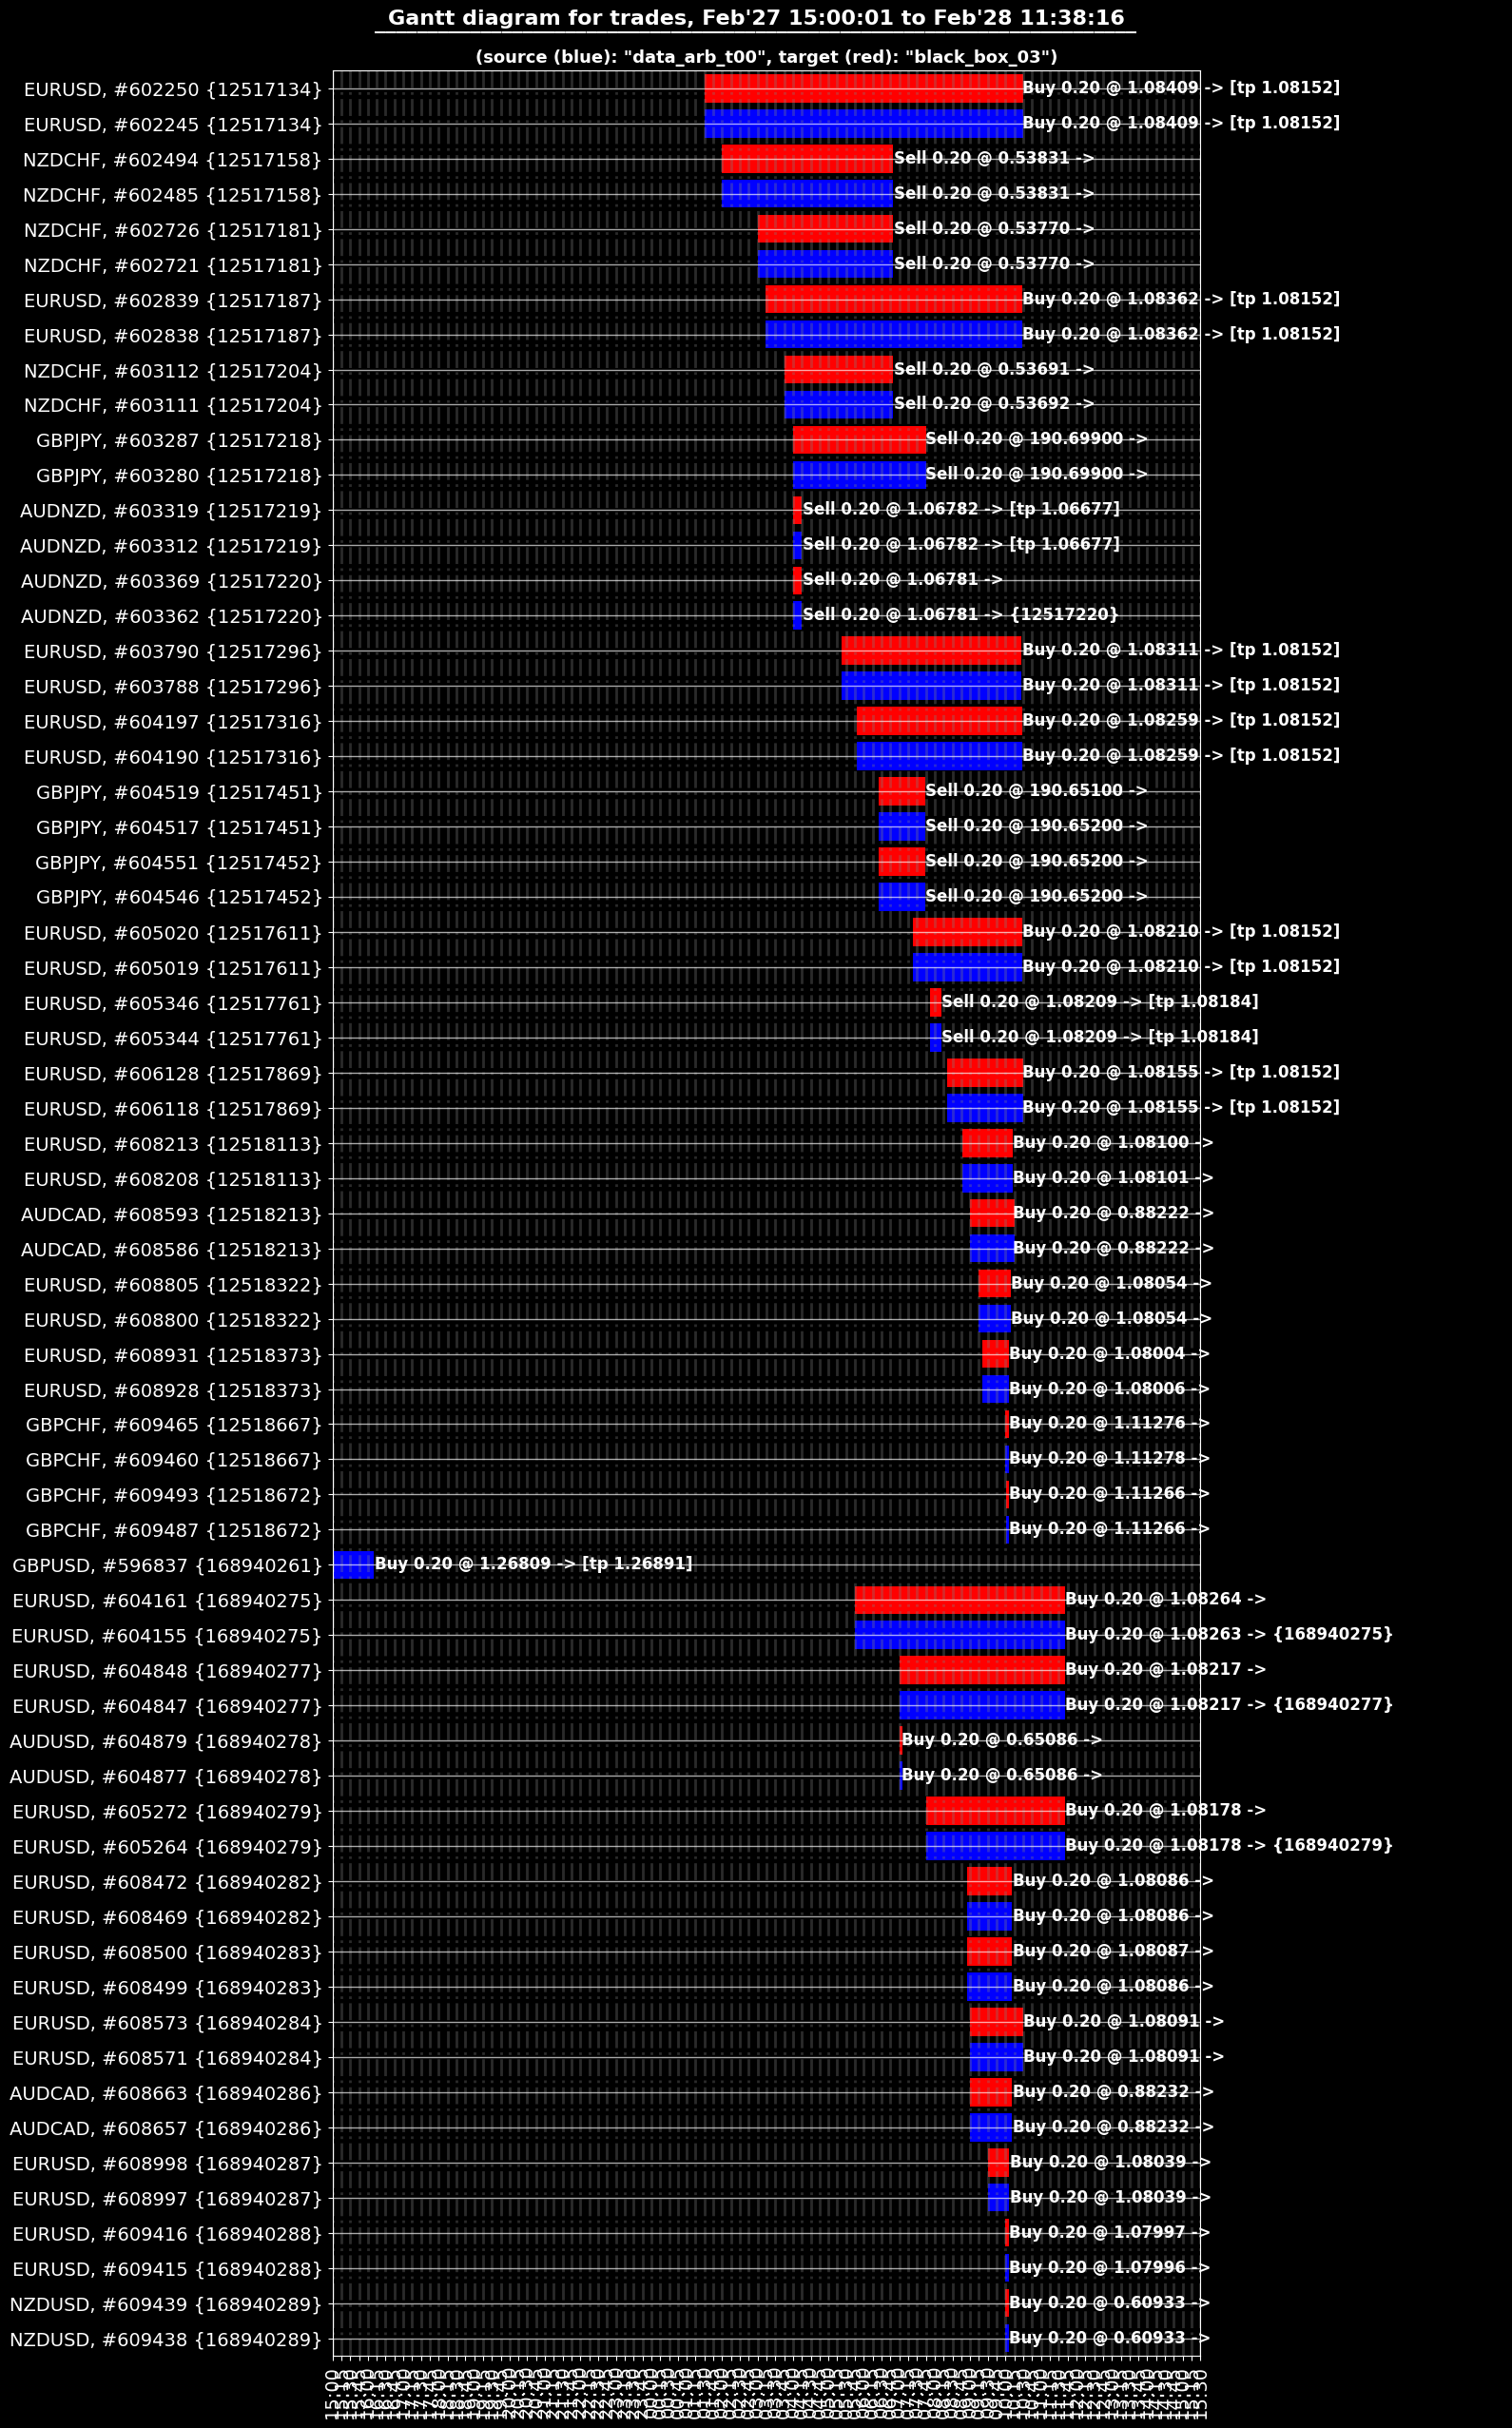

In [327]:
since: Timestamp = min(*df_source["t_entry"], *df_target["t_entry"])
until: Timestamp = max(*df_source["t_exit"], *df_target["t_exit"])
since_str, until_str = since.strftime(DT_FORMAT_STR), until.strftime(DT_FORMAT_STR)
since_fn, until_fn = since.strftime(DT_FORMAT_FN), until.strftime(DT_FORMAT_FN)
filename_gantt = f"gantt_{acc_source}_{acc_target}_{since_fn}_{until_fn}.jpg"

xticks_freq = Timedelta(minutes = 15)
xticks_1 = since.floor(xticks_freq)
xticks_2 = until.ceil(xticks_freq) + 15 * xticks_freq
xticks = date_range(start = xticks_1, end = xticks_2, freq = xticks_freq)
xlabels = xticks.strftime("%H:%M")

df_gantt = concat([df_source, df_target]).sort_values("test")
df_gantt["duration"] = df_gantt["t_exit"] - df_gantt["t_entry"]
df_gantt["duration"] = df_gantt["duration"].dt.ceil(Timedelta(minutes = 5))
df_gantt = df_gantt.set_index("ticket").iloc[:: -1]
n_trades = df_gantt.shape[0]

df_gantt["y_label"] = df_gantt.index
y_label = "{0[symbol]}, #{0[y_label]} {0[test]}"
df_gantt["y_label"] = df_gantt.agg(y_label.format, axis = "columns")
df_gantt["y_label"] = df_gantt["y_label"].str.strip(" ")

bar_text = "{0[order]} {0[lots]:.2f} @ {0[p_entry]:.5f} -> {0[close]}"
df_gantt["text"] = df_gantt.agg(bar_text.format, axis = "columns")

fig, ax = subplots(1, 1, figsize = (16, int(n_trades / 2.5)))

title = f"Gantt diagram for trades, {since_str} to {until_str}"
title += "\n" + "‾" * int(len(title) * 1.2)
fig.suptitle(title, fontsize = 16, fontweight = "bold")
ax.grid(True, axis = "x", alpha = 1/3, color = "gray", lw = 2, ls = "-.")
ax.grid(True, axis = "y", alpha = 2/3, color = "white", lw = 1, ls = "-")
ax.tick_params(labelsize = (ticksize := 14))
title = f"\n(source (blue): \"{acc_source}\", target (red): \"{acc_target}\")"
ax.set_title(title, fontsize = 13, fontweight = "bold")

cat_to_color = dict(source = "blue", target = "red")

verbose = "\rTracing trade #{n_tr}/%d: ticket #{ticket}, {category} account"
verbose = (verbose % n_trades) + ", {symbol} @ {t_entry} - {t_exit}"
ax.barh(y = (yticks := list(range(1, n_trades + 1))),
    color = df_gantt["category"].map(cat_to_color),
    width = df_gantt["duration"].values,
    left = df_gantt["t_entry"].values)

args = dict(fontsize = 12, fontweight = "bold", ha = "left", va = "center")
for n, (ticket, info) in enumerate(df_gantt.iterrows(), 1):
    ax.text(x = info["t_exit"] + xticks_freq / 6, y = n, s = info["text"], **args)

ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, rotation = 90, fontsize = ticksize)
ax.set_ylim(0.5, n_trades + 0.5)
ax.set_yticks(yticks)
ax.set_yticklabels(df_gantt["y_label"], fontsize = ticksize)
    
fig.set_tight_layout(True)
fig.savefig("../logs/" + filename_gantt, dpi = 200)

<hr><hr>

<h4><font color = "tomato"><b><u>Coupling</u></b></font></h4>

In [328]:
if "point" in df_source.columns:
    df_point = df_source.groupby("symbol")["point"].first()
    df_source.pop("point"), df_target.pop("point")

COLUMNS_SOURCE = dict(symbol = "symbol", lots = "lots_s", order = "order", 
    ticket = "ticket_s",  t_entry = "t_entry_s", t_exit = "t_exit_s",
    p_entry = "p_entry_s", p_exit = "p_exit_s", close = "close_s", test = "test")

COLUMNS_TARGET = dict(lots = "lots_t", source = "ticket_s",
    ticket = "ticket_t",  t_entry = "t_entry_t", t_exit = "t_exit_t",
    p_entry = "p_entry_t", p_exit = "p_exit_t", close = "close_t", test = "test")

df_source["test"] = df_target["test"] = "Feb'27"

COLUMNS_INDEX = ["test", "ticket_s"]

df_joined = merge(on = COLUMNS_INDEX, how = "outer",
    left  = df_source[list(COLUMNS_SOURCE)].rename(columns = COLUMNS_SOURCE),
    right = df_target[list(COLUMNS_TARGET)].rename(columns = COLUMNS_TARGET),
)
#print("Available tests:\n%s" % df_joined.groupby("test")["test"].count())
df_joined = df_joined.set_index(COLUMNS_INDEX).sort_index()

In [333]:
df.query("symbol == 'GBPJPY'")

,symbol,lots_s,order,t_entry_s,t_exit_s,p_entry_s,p_exit_s,close_s,lots_t,ticket_t,t_entry_t,t_exit_t,p_entry_t,p_exit_t,close_t,dp_entry,dp_exit,dt_entry,dt_exit
ticket_s,,,,,,,,,,,,,,,,,,,
603280,GBPJPY,0.2,Sell,2024-02-28 04:00:03.312,2024-02-28 07:41:22.834,190.699,190.634,,0.2,603287,2024-02-28 04:00:03.530,2024-02-28 07:41:23.004,190.699,190.634,,0.0,0.0,218,170
604517,GBPJPY,0.2,Sell,2024-02-28 06:24:37.530,2024-02-28 07:41:30.088,190.652,190.635,,0.2,604519,2024-02-28 06:24:37.697,2024-02-28 07:41:30.296,190.651,190.636,,-100.0,100.0,167,208
604546,GBPJPY,0.2,Sell,2024-02-28 06:24:38.565,2024-02-28 07:41:26.711,190.652,190.635,,0.2,604551,2024-02-28 06:24:38.710,2024-02-28 07:41:26.863,190.652,190.635,,0.0,0.0,145,152


In [329]:
thr, test = 2.5, "Feb'27"

tickets_test_s = Index(df_source.loc[df_source["test"].eq(test), "ticket"])
tickets_test_t = Index(df_target.loc[df_target["test"].eq(test), "source"])
tickets_test_common = Index.intersection(tickets_test_s, tickets_test_t)

df = df_joined.xs(key = test, level = "test").copy()
df_pt_map = df["symbol"].map(df_point)

df["dp_entry"] = (df_pt_map * (df["p_entry_t"] - df["p_entry_s"])).round(0)
df["dp_exit"] = (df_pt_map * (df["p_exit_t"] - df["p_exit_s"])).round(0)
df["dt_entry"] = (df["t_entry_t"] - df["t_entry_s"]).dt.total_seconds()
df["dt_exit"] = (df["t_exit_t"] - df["t_exit_s"]).dt.total_seconds()
df["dt_entry"] = (df["dt_entry"] * 1e3).fillna(0).astype(int)
df["dt_exit"] = (df["dt_exit"] * 1e3).fillna(0).astype(int)

stats = {
    "Total trades": df.shape[0],
    "Total closed delayed": df.loc[df["dt_exit"].ge(thr)].shape[0],
    "Total closed in sync": df.loc[df["dt_exit"].between(0, thr)].shape[0],
    "Total closed in advance": df.loc[df["dt_exit"].lt(0)].shape[0],
    "Total not copied": tickets_test_s.shape[0] - tickets_test_common.shape[0],
    "Delay, entry, min (ms)": df["dt_entry"].min(),
    "Delay, entry, mean (ms)": df["dt_entry"].mean(),
    "Delay, entry, max (ms)": df["dt_entry"].max(),
    "Delay, exit, min (ms)": df["dt_exit"].min(),
    "Delay, exit, mean (ms)": df["dt_exit"].mean(),
    "Delay, exit, max (ms)": df["dt_exit"].max(),
    "Slippage, entry, min (pts)": df["dp_entry"].min(),
    "Slippage, entry, mean (pts)": df["dp_entry"].mean(),
    "Slippage, entry, max (pts)": df["dp_entry"].max(),
    "Slippage, exit, min (pts)": df["dp_exit"].min(),
    "Slippage, exit, mean (pts)": df["dp_exit"].mean(),
    "Slippage, exit, max (pts)": df["dp_exit"].max(),
}

counter_s = df.loc[df["t_exit_s"].notna(), ["t_entry_s", "t_exit_s"]]
counter_t = df.loc[df["t_exit_t"].notna(), ["t_entry_t", "t_exit_t"]]
counter_s: Series = concat(axis = "index", objs = (
    Series(index = counter_s["t_entry_s"], data = +1),
    Series(index = counter_s["t_exit_s"], data = -1)))
counter_t: Series = concat(axis = "index", objs = (
    Series(index = counter_t["t_entry_t"], data = +1),
    Series(index = counter_t["t_exit_t"], data = -1)))

counter_s = counter_s.sort_index().cumsum()
counter_t = counter_t.sort_index().cumsum()
n_orders_s: Series = counter_s.diff().fillna(1)
n_orders_t: Series = counter_t.diff().fillna(1)
n_orders_s = n_orders_s.loc[n_orders_s > 0].cumsum()
n_orders_t = n_orders_t.loc[n_orders_t > 0].cumsum()

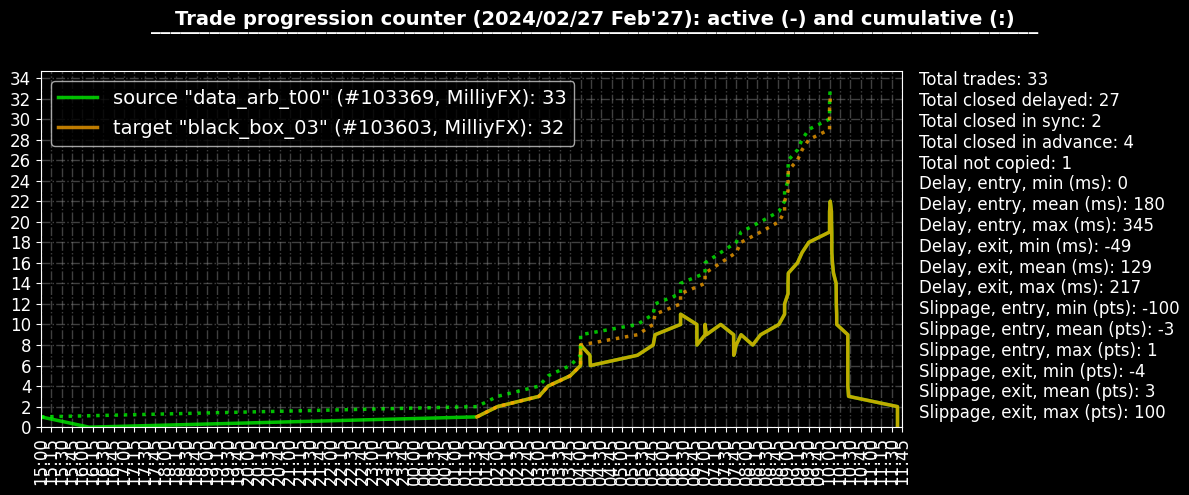

In [330]:
date = Timestamp.strftime(counter_s.index[0], "%Y/%m/%d")
date_fn = Timestamp.strftime(counter_s.index[0], "%Y.%m.%d")
filename_format = "matching_{date}_{test}_{source}_{target}.jpg".format
filename = filename_format(date = date_fn, test = test.replace(":", "."),
                            source = acc_source, target = acc_target)

fig, ax = subplots(figsize = (12, 5))

alpha = 0.75
ax.plot(counter_s, label = "source", lw = 2.5, alpha = alpha, color = "lime")
ax.plot(counter_t, label = "target", lw = 2.5, alpha = alpha, color = "orange")
ax.grid(True, ls = "-.", color = "gray", alpha = 0.5, lw = 1)

freq = Timedelta(minutes = 15)
since, until = counter_s.index[[0, -1]].floor(freq)

legend = {
    "source": [acc_source, accounts.at[acc_source, "id"],
        accounts.at[acc_source, "broker"], n_orders_s.iloc[-1]],
    "target": [acc_target, accounts.at[acc_target, "id"],
        accounts.at[acc_target, "broker"], n_orders_t.iloc[-1]]
}
ax.plot(n_orders_s, label = "", lw = 2.5, alpha = alpha, ls = ":", color = "lime")
ax.plot(n_orders_t, label = "", lw = 2.5, alpha = alpha, ls = ":", color = "orange")

ax.set_xticks(xticks := date_range(since, until + freq, freq = freq))
t_format = "%H:%M:%S" if (freq < Timedelta(seconds = 60)) else "%H:%M"
ax.set_xticklabels(xticks.strftime(t_format), rotation = 90)

ax.set_xlim(*xticks[[0, -1]])
n_yticks = len(ax.get_yticks())
ymax = max(n_orders_s.max(), n_orders_t.max())
ax.set_ylim(0, ymax * 1.05)
n_max = min(n_orders_s.max() + 1, n_orders_t.max() + 1, 2 * n_yticks)
ax.yaxis.set_major_locator(MaxNLocator(n_max))
ax.tick_params(labelsize = 12)
text_stats = str.join("\n", [f"%s: %d" % KV for KV in stats.items()])
ax.text(1.02, 1.0, s = text_stats, transform = ax.transAxes, va = "top", fontsize = 12) #

legend_format = "{} \"{}\" (#{}, {}): {:.0f}".format
legend = [legend_format(K, *V) for K, V in legend.items()]
ax.legend(legend, fontsize = 14, loc = "upper left")
title = "Trade progression counter (%s %s)" % (date, test)
title += ": active (-) and cumulative (:)"
title += "\n" + "‾" * int(len(title) * 1.2)
fig.suptitle(title, fontsize = 14, fontweight = "bold")
fig.set_tight_layout(True)
fig.savefig("../logs/" + filename, dpi = 200)

In [66]:
from PIL import Image

# Open all 8 images
image_files = os.listdir("../logs/")
images = [Image.open("../logs/" + file) for file in image_files]

# Ensure all images have the same dimensions (1600x900)
width, height = images[0].size
for img in images:
    assert img.size == (2400, 1000), "All images should be 1600x900"

# Create a new blank image with the required size for the grid (2 columns x 4 rows)
grid_width = 2400 * 2
grid_height = 1000 * 4
grid = Image.new("RGB", (grid_width, grid_height))

# Paste each image onto the grid
for i in range(8):
    x = (i % 2) * 2400
    y = (i // 2) * 1000
    grid.paste(images[i], (x, y))

# Save the final grid image
grid.save("grid_image.jpg")

<hr><hr><hr><hr>

In [3]:
token = "******"
url_base = "https://mt5.mtapi.be/"
url = url_base + "Symbols" + "?id=" + token
resp = requests.get(url)
the_list = dict()

verb = "\rSymbol #%d/%d: \"%s\" (eta: %.1f mins)"
delay = 9999

if (resp.status_code == 200):
    symbols = Index(resp.json().keys())
    N = symbols.shape[0]
    for n, symbol in enumerate(symbols, 1):
        t = time.time()
        if symbol in the_list: continue
        url = url_base + "SymbolParams" + "?id=" + token
        url = url + "&symbol=" + symbol
        print(verb % (n, N, url, (N - n) * delay / 60), end = "")
        resp = requests.get(url); time.sleep(0.25)
        delay = int(time.time() - t) + 1
        if (resp.status_code == 200):
            the_list[symbol] = DataFrame(resp.json())
        else: print("\nError:\n%s\n" % resp.text); continue

the_list: DataFrame = concat(the_list)

symbols = the_list.rename_axis(["name", "field"])["symbolInfo"].dropna().unstack("field")
groups = the_list.rename_axis(["name", "field"])["symbolGroup"].dropna().unstack("field")

rename_symbols = dict(
    marginCurrency = "quote",
    profitCurrency = "base",
    digits = "digits", points = "point",
    contractSize = "contract",
    description = "description",
)
symbols = symbols[rename_symbols.keys()].rename(columns = rename_symbols)

rename_groups = dict(
    tradeMode = "status",
    sl = "min_sl", tp = "min_tp",
    groupName = "class",
    minLots = "lot_min",
    maxLots = "lot_max",
    lotsStep = "lot_step",
    deviationRate = "dev_rate",
)
groups = groups[rename_groups.keys()].rename(columns = rename_groups)

df = merge(symbols, groups, left_index = True, right_index = True, how = "inner")
df["class"] = df["class"].str.split("\\").str[0]
df["server"] = "myServer"
df.query("`class` == 'Forex'")
is_crypto = df["class"].str.contains("Crypto")
df.loc[is_crypto, "quote"] = df.loc[is_crypto].index.str.replace("USD", "")
is_index = df["quote"].eq(df["base"])
df.loc[is_index, "quote"] = ""
df["min_stop"] = df[["min_sl", "min_tp"]].max(axis = "columns")

df["standard"] = df.index.str.split(".").str[0]
df["standard"] = df["standard"].str.replace("_.*", "", regex = True)
df = df[["server", "standard", "class", "quote", "base", "point", "digits", "contract", "min_stop", "lot_min", "lot_max", "lot_step", "dev_rate", "description"]]
df = df.rename_axis("symbol").reset_index().set_index(["server", "class", "standard"]).sort_index().reset_index().set_index(["symbol"])
#df.to_sql("tc_symbols", DB_URL, index = True, if_exists = "append")
df

Symbol #291/291: "https://mt5.mtapi.be/SymbolParams?id=2bdcbfef-159b-4a59-9c30-da8286838852&symbol=Drift Switch Index 10" (eta: 0.0 mins)ins)

field,server,class,standard,quote,base,point,digits,contract,min_stop,lot_min,lot_max,lot_step,dev_rate,description
symbol,,,,,,,,,,,,,,
AUD Basket,myServer,Basket Indices,AUD Basket,,USD,0.001,3,100.0,5,0.01,5.0,0.01,40,"AUD vs equally weighted basket of (USD,EUR,GBP..."
EUR Basket,myServer,Basket Indices,EUR Basket,,USD,0.001,3,100.0,5,0.01,5.0,0.01,27,"EUR vs equally weighted basket of (USD,AUD,GBP..."
GBP Basket,myServer,Basket Indices,GBP Basket,,USD,0.001,3,100.0,5,0.01,5.0,0.01,28,"GBP vs equally weighted basket of (USD,EUR,AUD..."
Gold Basket,myServer,Basket Indices,Gold Basket,,USD,0.001,3,1.0,5,0.01,1.0,0.01,77660,"XAU vs equally weighted basket of (USD,EUR,AUD..."
USD Basket,myServer,Basket Indices,USD Basket,,USD,0.001,3,100.0,5,0.01,5.0,0.01,23,"USD vs equally weighted basket of (EUR,GBP,JPY..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Volatility 300 (1s) Index,myServer,Volatility Indices,Volatility 300 (1s) Index,,USD,0.01,2,1.0,3,1.0,30.0,0.01,0,Constant Volatility of 300% with a tick every ...
Volatility 50 (1s) Index,myServer,Volatility Indices,Volatility 50 (1s) Index,,USD,0.01,2,1.0,15000,0.005,1.0,0.001,0,Constant Volatility of 50% with a tick every 1...
Volatility 50 Index,myServer,Volatility Indices,Volatility 50 Index,,USD,0.0001,4,1.0,800,4.0,1000.0,0.01,0,Constant Volatility of 50% with a tick every 2...
